# Cek Jenis-Jenis Barang di Foto

In [1]:
import pandas as pd

df = pd.read_csv(
    "data/styles.csv",
    engine="python",
    on_bad_lines="skip"   
)

print(df.columns)
print(df['articleType'].unique()[:20])


Index(['id', 'gender', 'masterCategory', 'subCategory', 'articleType',
       'baseColour', 'season', 'year', 'usage', 'productDisplayName'],
      dtype='object')
['Shirts' 'Jeans' 'Watches' 'Track Pants' 'Tshirts' 'Socks' 'Casual Shoes'
 'Belts' 'Flip Flops' 'Handbags' 'Tops' 'Bra' 'Sandals' 'Shoe Accessories'
 'Sweatshirts' 'Deodorant' 'Formal Shoes' 'Bracelet' 'Lipstick' 'Flats']


# Filter Menjadi 4 Macam dengan Jumlah Sama

In [3]:
selected_categories = ["Tshirts", "Casual Shoes", "Handbags", "Jeans"]

filtered_df = df[df["articleType"].isin(selected_categories)]

print(filtered_df["articleType"].value_counts())

articleType
Tshirts         7067
Casual Shoes    2845
Handbags        1759
Jeans            609
Name: count, dtype: int64


In [4]:
balanced_df = (
    filtered_df
    .groupby("articleType")
    .sample(n=600, random_state=42)
    .reset_index(drop=True)
)

print(balanced_df["articleType"].value_counts())
print("Total:", len(balanced_df))


articleType
Casual Shoes    600
Handbags        600
Jeans           600
Tshirts         600
Name: count, dtype: int64
Total: 2400


# Cek Gambar yang Tersedia

In [5]:
import os

image_folder = "data/images"

def image_exists(row):
    img_path = os.path.join(image_folder, f"{row['id']}.jpg")
    return os.path.exists(img_path)

balanced_df["exists"] = balanced_df.apply(image_exists, axis=1)
print(balanced_df["exists"].value_counts())


exists
True     2399
False       1
Name: count, dtype: int64


In [6]:
balanced_df = balanced_df[balanced_df["exists"] == True].drop(columns=["exists"])
print(len(balanced_df))


2399


# Memilih Gambara yang digunakan dan dipisahkan ke Folder yang berbeda

In [8]:
import shutil
import os

image_folder = "data/images"
selected_folder = "data/selected_images"

os.makedirs(selected_folder, exist_ok=True)

for _, row in balanced_df.iterrows():
    src = os.path.join(image_folder, f"{row['id']}.jpg")
    dst = os.path.join(selected_folder, f"{row['id']}.jpg")
    shutil.copy(src, dst)

print("Done copying images.")


Done copying images.


# Validasi Distribusi

In [9]:
print(balanced_df["articleType"].value_counts())
print("Total images:", len(balanced_df))


articleType
Casual Shoes    600
Handbags        600
Tshirts         600
Jeans           599
Name: count, dtype: int64
Total images: 2399


# Visualisasi Gambar per Kategori

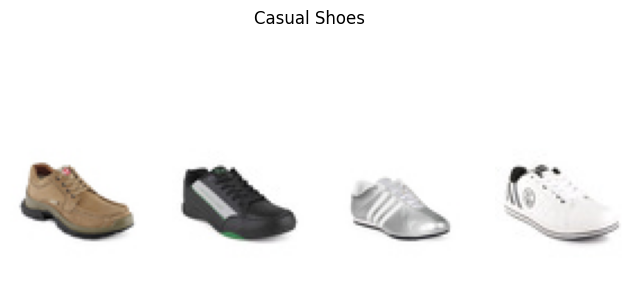

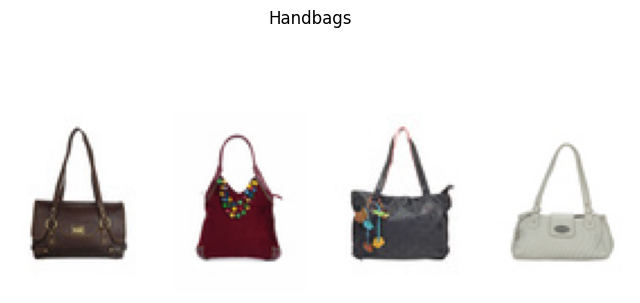

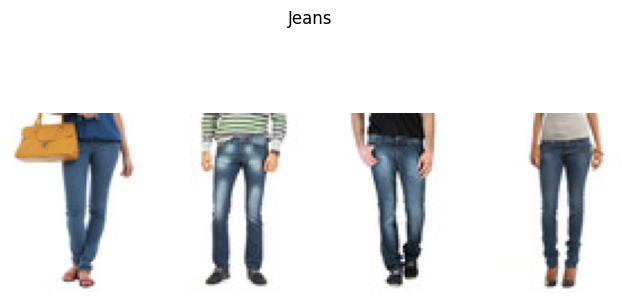

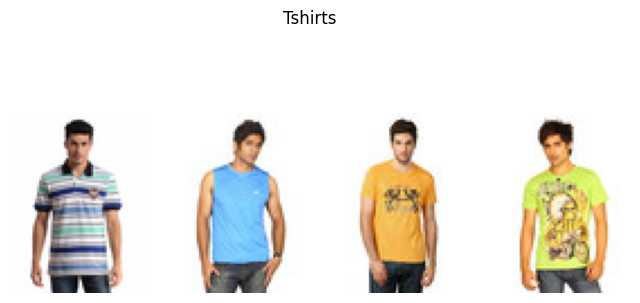

In [10]:
import matplotlib.pyplot as plt
from PIL import Image
import os

selected_folder = "data/selected_images"

categories = balanced_df["articleType"].unique()

for category in categories:
    sample = balanced_df[balanced_df["articleType"] == category].sample(4, random_state=42)
    
    plt.figure(figsize=(8,4))
    plt.suptitle(category)
    
    for i, (_, row) in enumerate(sample.iterrows()):
        img_path = os.path.join(selected_folder, f"{row['id']}.jpg")
        img = Image.open(img_path).convert("RGB")
        
        plt.subplot(1,4,i+1)
        plt.imshow(img)
        plt.axis("off")
    
    plt.show()


# Cek Resolusi Gambar

In [11]:
sizes = []

for _, row in balanced_df.sample(100, random_state=42).iterrows():
    img_path = os.path.join(selected_folder, f"{row['id']}.jpg")
    img = Image.open(img_path)
    sizes.append(img.size)

print("Contoh ukuran gambar (width, height):")
print(sizes[:10])


Contoh ukuran gambar (width, height):
[(60, 80), (60, 80), (60, 80), (60, 80), (60, 80), (60, 80), (60, 80), (60, 80), (60, 80), (60, 80)]
